In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv('data.csv')
df.columns = df.columns.str.strip()

ft_space = ['amazement', 'solemnity', 'tenderness', 'nostalgia', 'calmness', 'power', 'joyful_activation', 'tension', 'sadness', 'liked', 'disliked']

df = df.groupby("track id").agg({**{col: 'mean' for col in ft_space}, 'genre': 'first'}).reset_index()

In [5]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df["genre_enc"] = le.fit_transform(df["genre"])

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   track id           400 non-null    int64  
 1   amazement          400 non-null    float64
 2   solemnity          400 non-null    float64
 3   tenderness         400 non-null    float64
 4   nostalgia          400 non-null    float64
 5   calmness           400 non-null    float64
 6   power              400 non-null    float64
 7   joyful_activation  400 non-null    float64
 8   tension            400 non-null    float64
 9   sadness            400 non-null    float64
 10  liked              400 non-null    float64
 11  disliked           400 non-null    float64
 12  genre              400 non-null    object 
 13  genre_enc          400 non-null    int64  
dtypes: float64(11), int64(2), object(1)
memory usage: 43.9+ KB


In [ ]:
df.sample(1)

genre
classical     20
electronic    20
pop           20
rock          20
Name: count, dtype: int64
Total samples: 80


/tmp/ipykernel_6572/551946458.py:2: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sampled_df = df.groupby('genre').apply(lambda x: x.sample(20, random_state=42)).reset_index(drop=True)


In [15]:
from sklearn.model_selection import train_test_split

X = df[ft_space]
y = df['genre_enc']

train, test = train_test_split(df, test_size=320, random_state=0, stratify=df['genre_enc'])

X_test = test[ft_space]
y_test = test['genre_enc']

train = train[ft_space + ['genre_enc']]

In [ ]:
from sdv.metadata import Metadata
metadata = Metadata.detect_from_dataframe(data=(train))

In [17]:
from sdv.single_table import GaussianCopulaSynthesizer
gc = GaussianCopulaSynthesizer(metadata)
gc.fit(train)

/mnt/HDD_2/ml/venv/lib/python3.12/site-packages/sdv/single_table/base.py:134: UserWarning: We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.
  warnings.warn(


In [18]:
X_train = train[ft_space]
y_train = train['genre_enc']

In [19]:
train_synth_dot25N_1 = gc.sample(int(len(train) / 4))
train_dot25N_1 = pd.concat([train, train_synth_dot25N_1], ignore_index=True)

X_train_dot25N_1 = train_dot25N_1[ft_space]
y_train_dot25N_1 = train_dot25N_1['genre_enc']

In [20]:
train_synth_dot33N_1 = gc.sample(int(len(train) / 3))
train_dot33N_1 = pd.concat([train, train_synth_dot33N_1], ignore_index=True)

X_train_dot33N_1 = train_dot33N_1[ft_space]
y_train_dot33N_1 = train_dot33N_1['genre_enc']

In [21]:
train_synth_dot5N_1 = gc.sample(int(len(train) / 2))
train_dot5N_1 = pd.concat([train, train_synth_dot5N_1], ignore_index=True)

X_train_dot5N_1 = train_dot5N_1[ft_space]
y_train_dot5N_1 = train_dot5N_1['genre_enc']

In [22]:
train_synth_N_1 = gc.sample(len(train))
train_N_1 = pd.concat([train, train_synth_N_1], ignore_index=True)

X_train_N_1 = train_N_1[ft_space]
y_train_N_1 = train_N_1['genre_enc']

In [28]:
train_synth_2N_1 = gc.sample(2 * len(train))
train_2N_1 = pd.concat([train, train_synth_2N_1], ignore_index=True)

X_train_2N_1 = train_2N_1[ft_space]
y_train_2N_1 = train_2N_1['genre_enc']

In [23]:
train_synth_4N_1 = gc.sample(4 * len(train))
train_4N_1 = pd.concat([train, train_synth_4N_1], ignore_index=True)

X_train_4N_1 = train_4N_1[ft_space]
y_train_4N_1 = train_4N_1['genre_enc']

In [24]:
train_synth_8N_1 = gc.sample(8 * len(train))
train_8N_1 = pd.concat([train, train_synth_8N_1], ignore_index=True)

X_train_8N_1 = train_8N_1[ft_space]
y_train_8N_1 = train_8N_1['genre_enc']

In [15]:
# train_dot5N.info()
# train_N.info()
# train_2N.info()
# train_4N.info()
# train_8N.info()

In [32]:
from xgboost import XGBClassifier
import time
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform

def random_search(clf, x, y):

    param_dist = {
        "n_estimators": randint(50, 500),
        "max_depth": randint(2, 9),
        "learning_rate": [0.01, 0.05, 0.1, 0.2],
        "subsample": [0.6, 0.8, 1.0],
        "colsample_bytree": [0.6, 0.8, 1.0],
        "min_child_weight": uniform(1, 5)
    }

    random_search = RandomizedSearchCV(
        estimator=clf,
        param_distributions=param_dist,
        n_iter=200,
        cv=5,
        scoring='accuracy',
        random_state=1,
        n_jobs=-1,
        verbose=0
    )

    start_time = time.time()

    random_search.fit(x, y)

    end_time = time.time()
    runtime = end_time - start_time

    print("Best parameters:", random_search.best_params_)

    best_model = random_search.best_estimator_
    test_score = best_model.score(X_test, y_test)
    print(f"Test Accuracy: {test_score}")

    print(f"Total runtime: {runtime:.2f} seconds ({runtime/60:.2f} minutes)")

    return random_search.best_params_, test_score, runtime

In [30]:
def run_random_searches(dataset_list):
    results = []
    for label, X, y in dataset_list:
        clf = XGBClassifier()
        result = random_search(clf, X, y)
        results.append((label, result))
    return results

In [33]:
dataset_list_1 = [
    ('OG', X_train, y_train),
    ('dot25N', X_train_dot25N_1, y_train_dot25N_1),
    ('dot33N', X_train_dot33N_1, y_train_dot33N_1),
    ('dot5N', X_train_dot5N_1, y_train_dot5N_1),
    ('N', X_train_N_1, y_train_N_1),
    ('2N', X_train_2N_1, y_train_2N_1),
    ('4N', X_train_4N_1, y_train_4N_1),
    ('8N', X_train_8N_1, y_train_8N_1),
]

results_randomsearchcv_gaussian = run_random_searches(dataset_list_1)

print(results_randomsearchcv_gaussian)

Best parameters: {'colsample_bytree': 0.6, 'learning_rate': 0.1, 'max_depth': 8, 'min_child_weight': np.float64(4.148587535107822), 'n_estimators': 255, 'subsample': 1.0}
Test Accuracy: 0.61875
Total runtime: 33.51 seconds (0.56 minutes)
Best parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.2, 'max_depth': 4, 'min_child_weight': np.float64(4.374858024045526), 'n_estimators': 117, 'subsample': 0.8}
Test Accuracy: 0.578125
Total runtime: 38.25 seconds (0.64 minutes)
Best parameters: {'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 6, 'min_child_weight': np.float64(2.2492534011251837), 'n_estimators': 405, 'subsample': 1.0}
Test Accuracy: 0.553125
Total runtime: 40.82 seconds (0.68 minutes)
Best parameters: {'colsample_bytree': 0.6, 'learning_rate': 0.1, 'max_depth': 2, 'min_child_weight': np.float64(2.3214874136345034), 'n_estimators': 50, 'subsample': 0.8}
Test Accuracy: 0.53125
Total runtime: 45.52 seconds (0.76 minutes)
Best parameters: {'colsample_bytree': 1.0, 'l

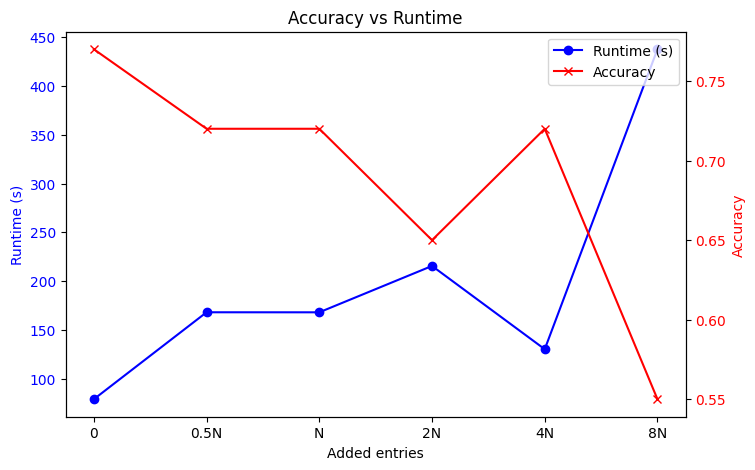

In [19]:
X_results = [0.77, 0.72, 0.72, 0.65, 0.72, 0.55]
Y_results = ['0', '0.5N', 'N', '2N', '4N', '8N']
runtime_results = [78.98, 168.09, 168.05, 215.56, 130.23, 437.68]

fig, ax1 = plt.subplots(figsize=(8,5))

# Plot runtime on primary y-axis
ax1.plot(Y_results, runtime_results, color='blue', marker='o', label='Runtime (s)')
ax1.set_xlabel('Added entries')
ax1.set_ylabel('Runtime (s)', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

# Create secondary y-axis for accuracy
ax2 = ax1.twinx()
ax2.plot(Y_results, X_results, color='red', marker='x', label='Accuracy')
ax2.set_ylabel('Accuracy', color='red')
ax2.tick_params(axis='y', labelcolor='red')

# Legends (combine from both axes)
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper right')

plt.title('Accuracy vs Runtime')
plt.show()

In [2]:
# Why inversely correlated? Seems like runtime is mostly determined by #entries and max_depth: More entries means more noise and higher max_depth means lower accuracy?

In [21]:
from sdv.single_table import CTGANSynthesizer

ctgan = CTGANSynthesizer(metadata, cuda=False)
ctgan.fit(train)

/mnt/HDD_2/ml/venv/lib/python3.12/site-packages/ctgan/synthesizers/_utils.py:16: FutureWarning: `cuda` parameter is deprecated and will be removed in a future release. Please use `enable_gpu` instead.
  warnings.warn(


In [31]:
train_synth_dot25N_2 = ctgan.sample(int(len(train) / 4))
train_dot25N_2 = pd.concat([train, train_synth_dot25N_2], ignore_index=True)

X_train_dot25N_2 = train_dot25N_2[ft_space]
y_train_dot25N_2 = train_dot25N_2['genre_enc']

In [32]:
train_synth_dot33N_2 = ctgan.sample(int(len(train) / 3))
train_dot33N_2 = pd.concat([train, train_synth_dot33N_2], ignore_index=True)

X_train_dot33N_2 = train_dot33N_2[ft_space]
y_train_dot33N_2 = train_dot33N_2['genre_enc']

In [22]:
train_synth_dot5N_2 = ctgan.sample(int(len(train) / 2))
train_dot5N_2 = pd.concat([train, train_synth_dot5N_2], ignore_index=True)

X_train_dot5N_2 = train_dot5N_2[ft_space]
y_train_dot5N_2 = train_dot5N_2['genre_enc']

In [23]:
train_synth_N_2 = ctgan.sample(len(train))
train_N_2 = pd.concat([train, train_synth_N_2], ignore_index=True)

X_train_N_2 = train_N_2[ft_space]
y_train_N_2 = train_N_2['genre_enc']

In [24]:
train_synth_2N_2 = ctgan.sample(2 * len(train))
train_2N_2 = pd.concat([train, train_synth_2N_2], ignore_index=True)

X_train_2N_2 = train_2N_2[ft_space]
y_train_2N_2 = train_2N_2['genre_enc']

In [25]:
train_synth_4N_2 = ctgan.sample(4 * len(train))
train_4N_2 = pd.concat([train, train_synth_4N_2], ignore_index=True)

X_train_4N_2 = train_4N_2[ft_space]
y_train_4N_2 = train_4N_2['genre_enc']

In [35]:
train_synth_8N_2 = ctgan.sample(8 * len(train))
train_8N_2 = pd.concat([train, train_synth_8N_2], ignore_index=True)

X_train_8N_2 = train_8N_2[ft_space]
y_train_8N_2 = train_8N_2['genre_enc']

In [33]:
dataset_list_2 = [
    ('OG', X_train, y_train),
    ('dot25N', X_train_dot25N_2, y_train_dot25N_2),
    ('dot33N', X_train_dot33N_2, y_train_dot33N_2),
    ('dot5N', X_train_dot5N_2, y_train_dot5N_2),
    ('N', X_train_N_2, y_train_N_2),
    ('2N', X_train_2N_2, y_train_2N_2),
    ('4N', X_train_4N_2, y_train_4N_2),
    ('8N', X_train_8N_2, y_train_8N_2),
]

results_randomsearchcv_ctgan = run_random_searches(dataset_list_2)

print(results_randomsearchcv_ctgan)

Best parameters: {'colsample_bytree': 0.6, 'learning_rate': 0.2, 'max_depth': 5, 'min_child_weight': np.float64(1.9316617166338), 'n_estimators': 420, 'subsample': 0.6}
Test Accuracy: 0.77
Total runtime: 68.97 seconds (1.15 minutes)
Best parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.2, 'max_depth': 3, 'min_child_weight': np.float64(4.4254599552529745), 'n_estimators': 258, 'subsample': 0.6}
Test Accuracy: 0.74
Total runtime: 90.88 seconds (1.51 minutes)
Best parameters: {'colsample_bytree': 0.6, 'learning_rate': 0.1, 'max_depth': 3, 'min_child_weight': np.float64(1.448015171193027), 'n_estimators': 345, 'subsample': 0.6}
Test Accuracy: 0.75
Total runtime: 102.85 seconds (1.71 minutes)
Best parameters: {'colsample_bytree': 0.6, 'learning_rate': 0.2, 'max_depth': 5, 'min_child_weight': np.float64(1.9316617166338), 'n_estimators': 420, 'subsample': 0.6}
Test Accuracy: 0.77
Total runtime: 114.07 seconds (1.90 minutes)
Best parameters: {'colsample_bytree': 0.8, 'learning_rate': 0